In [72]:
import sqlite3
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect("database.db")
cursor = conn.cursor()

cursor.execute("""
    CREATE TABLE IF NOT EXISTS performance (
        id INTEGER PRIMARY KEY,
        timestamp TEXT,
        cpu_usage REAL,
        rss INTEGER,
        vms INTEGER,
        action TEXT,
        pixels_changed INTEGER,
        canvas_area INTEGER,
        layers INTEGER
    )
""") # rss = resident set size (non-swapped physical memory)
    # vms = virtual memory size (total amount of virtual memory used)

conn.commit()
conn.close()

In [134]:
conn = sqlite3.connect("database.db")
cursor = conn.cursor()

cursor.execute("SELECT * FROM performance")
rows = cursor.fetchall()

for row in rows:
    print(f"ID: {row[0]} | Time: {row[1]} | CPU: {row[2]}% | RSS: {row[3]} | VMS: {row[4]} | Action: {row[5]} | Pixels: {row[6]} | Canvas Area: {row[7]} | Layers: {row[8]}")

conn.close()

ID: 1 | Time: 2026-05-03 09:15:21 | CPU: 0.0% | RSS: 111947776 | VMS: 1087623168 | Action: idle | Pixels: 0 | Canvas Area: 0 | Layers: 0
ID: 2 | Time: 2026-05-03 09:15:22 | CPU: 18.04375% | RSS: 155922432 | VMS: 1119571968 | Action: idle | Pixels: 0 | Canvas Area: 2073600 | Layers: 1
ID: 3 | Time: 2026-05-03 09:15:23 | CPU: 22.1% | RSS: 156618752 | VMS: 1124519936 | Action: idle | Pixels: 0 | Canvas Area: 2073600 | Layers: 1
ID: 4 | Time: 2026-05-03 09:15:23 | CPU: 16.4375% | RSS: 162152448 | VMS: 1125228544 | Action: preparing action | Pixels: 0 | Canvas Area: 2073600 | Layers: 1
ID: 5 | Time: 2026-05-03 09:15:24 | CPU: 12.81875% | RSS: 182468608 | VMS: 1145577472 | Action: shape_rectangle | Pixels: 430000 | Canvas Area: 2073600 | Layers: 1
ID: 6 | Time: 2026-05-03 09:15:24 | CPU: 60.51875% | RSS: 182554624 | VMS: 1145610240 | Action: preparing action | Pixels: 0 | Canvas Area: 2073600 | Layers: 1
ID: 7 | Time: 2026-05-03 09:15:24 | CPU: 0.0% | RSS: 188022784 | VMS: 1154076672 | Actio

In [74]:
conn = sqlite3.connect("database.db")
cursor = conn.cursor()
df = pd.read_sql("SELECT * FROM performance", conn)

df["total_area"]=df["canvas_area"]*df["layers"]
df

,id,timestamp,cpu_usage,rss,vms,action,pixels_changed,canvas_area,layers,total_area
0,1,2026-05-03 09:15:21,0.00000,111947776,1087623168,idle,0,0,0,0
1,2,2026-05-03 09:15:22,18.04375,155922432,1119571968,idle,0,2073600,1,2073600
2,3,2026-05-03 09:15:23,22.10000,156618752,1124519936,idle,0,2073600,1,2073600
3,4,2026-05-03 09:15:23,16.43750,162152448,1125228544,preparing action,0,2073600,1,2073600
4,5,2026-05-03 09:15:24,12.81875,182468608,1145577472,shape_rectangle,430000,2073600,1,2073600
...,...,...,...,...,...,...,...,...,...,...
5084,5085,2026-05-03 09:36:02,6.31875,10758545408,14490083328,preparing action,0,21000000,3,63000000
5085,5086,2026-05-03 09:36:03,21.73125,10725306368,14490091520,drawing,78732,21000000,3,63000000
5086,5087,2026-05-03 09:36:03,0.00000,10687639552,14490075136,idle,0,21000000,3,63000000
5087,5088,2026-05-03 09:36:04,21.51250,10759254016,14490025984,idle,0,21000000,3,63000000


In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5089 entries, 0 to 5088
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              5089 non-null   int64  
 1   timestamp       5089 non-null   str    
 2   cpu_usage       5089 non-null   float64
 3   rss             5089 non-null   int64  
 4   vms             5089 non-null   int64  
 5   action          5089 non-null   str    
 6   pixels_changed  5089 non-null   int64  
 7   canvas_area     5089 non-null   int64  
 8   layers          5089 non-null   int64  
 9   total_area      5089 non-null   int64  
dtypes: float64(1), int64(7), str(2)
memory usage: 397.7 KB


In [76]:
df.columns.tolist()

['id',
 'timestamp',
 'cpu_usage',
 'rss',
 'vms',
 'action',
 'pixels_changed',
 'canvas_area',
 'layers',
 'total_area']

In [77]:
df.describe()

,id,cpu_usage,rss,vms,pixels_changed,canvas_area,layers,total_area
count,5089.00000,5089.000000,5.089000e+03,5.089000e+03,5.089000e+03,5.089000e+03,5089.000000,5.089000e+03
mean,2545.00000,13.735708,4.314810e+09,8.766106e+09,7.024372e+05,1.656186e+07,2.269208,3.632181e+07
std,1469.21209,23.045757,3.417560e+09,9.005828e+09,5.883083e+06,2.173781e+07,0.603512,4.381252e+07
min,1.00000,0.000000,1.119478e+08,1.087623e+09,0.000000e+00,0.000000e+00,0.000000,0.000000e+00
25%,1273.00000,0.000000,9.524634e+08,1.918038e+09,0.000000e+00,2.073600e+06,2.000000,4.147200e+06
50%,2545.00000,6.806250,3.866943e+09,5.132481e+09,0.000000e+00,6.250000e+06,2.000000,1.875000e+07
75%,3817.00000,16.581250,7.120253e+09,1.122376e+10,1.433000e+04,1.600000e+07,3.000000,4.800000e+07
max,5089.00000,214.125000,1.164968e+10,3.141427e+10,6.710886e+07,6.710886e+07,3.000000,1.342177e+08


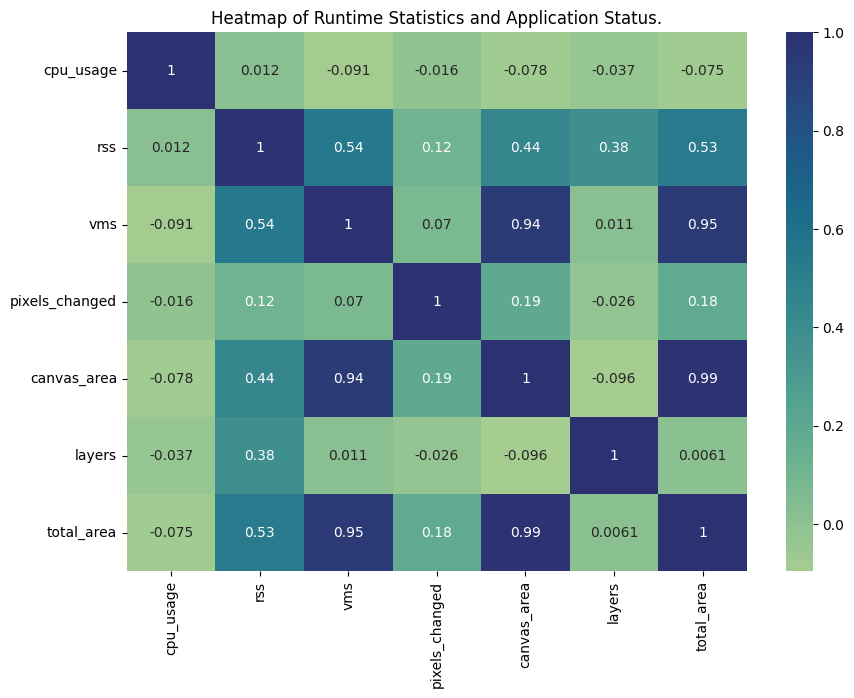

In [99]:
correlations = df.iloc[:, 1:].corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(correlations, annot=True, cmap="crest")
plt.title("Heatmap of Runtime Statistics and Application Status.")
plt.show()

The heatmap underscores a moderately positive correlation between resident set size (RSS), or physical main memory, and virtual memory (VMS). Additionally, RSS has a moderately positive correlation between itself and layers, total_area, and canvas_area, indicating that applications with larger canvases are more memory-intensive.

Moreover, VMS demonstrates an even sharper correlation between canvas_area and total_area, but little to no correlation to layers.


Unsurprisingly, canvas_area has a near perfect correlattion with total_area. However, cpu_usage does not appear to be closely related to any aspect of the program other than itself, including memory.

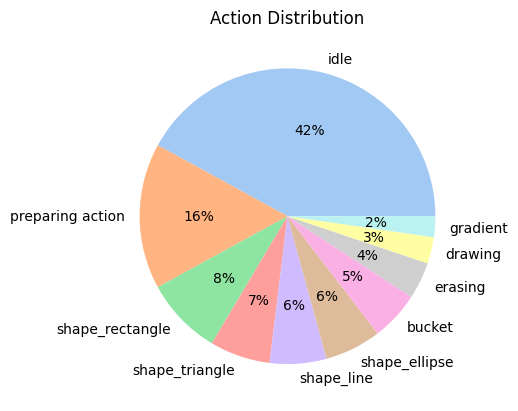

In [123]:
plt.pie(data= df, labels =df["action"].unique(), x=list(df["action"].value_counts()), colors=sns.color_palette("pastel"), autopct='%.0f%%')
plt.title("Action Distribution")
plt.show()

The majority of actions are recorded as not drawing. This large distribution is skewing the results. If we were to remove the inactivity, the chart would look more like the pie chart below.

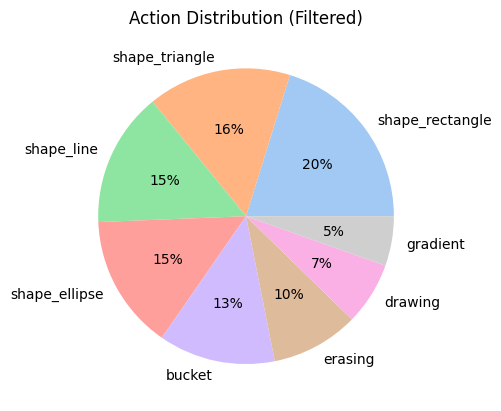

In [129]:
dfFiltered = df[(df["action"]!="preparing action") & (df["action"]!="idle")]
plt.pie(data= df, labels = dfFiltered["action"].unique(), x=list(dfFiltered["action"].value_counts()), colors=sns.color_palette("pastel"), autopct='%.0f%%')
plt.title("Action Distribution (Filtered)")
plt.show()

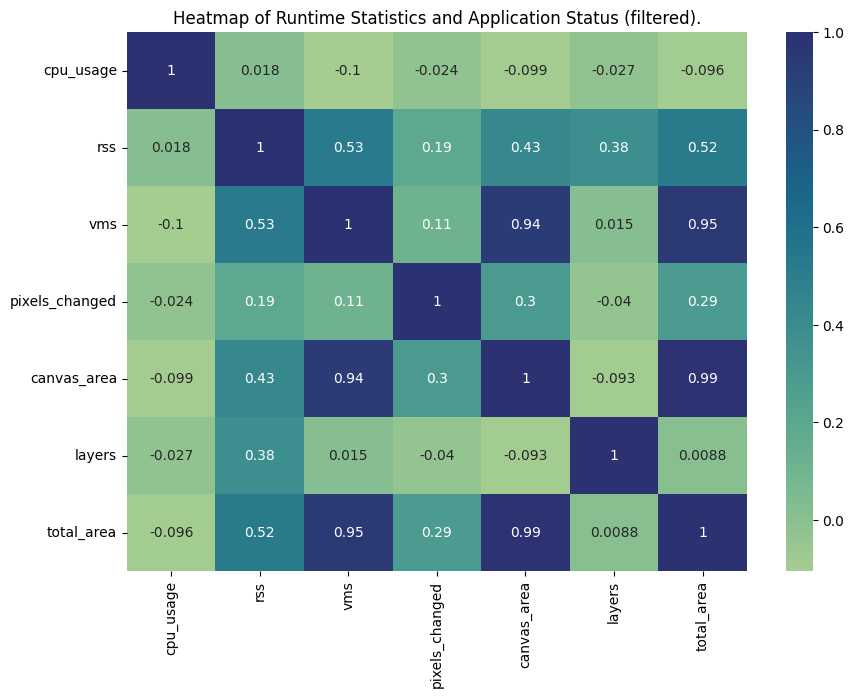

In [130]:
correlations = dfFiltered.iloc[:, 1:].corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(correlations, annot=True, cmap="crest")
plt.title("Heatmap of Runtime Statistics and Application Status (filtered).")
plt.show()

Now that the two inactive action types, the relationship between most other numeric measures has become more pronounced. For instance, total_area has increased by 0.1 (over a 50% increase).

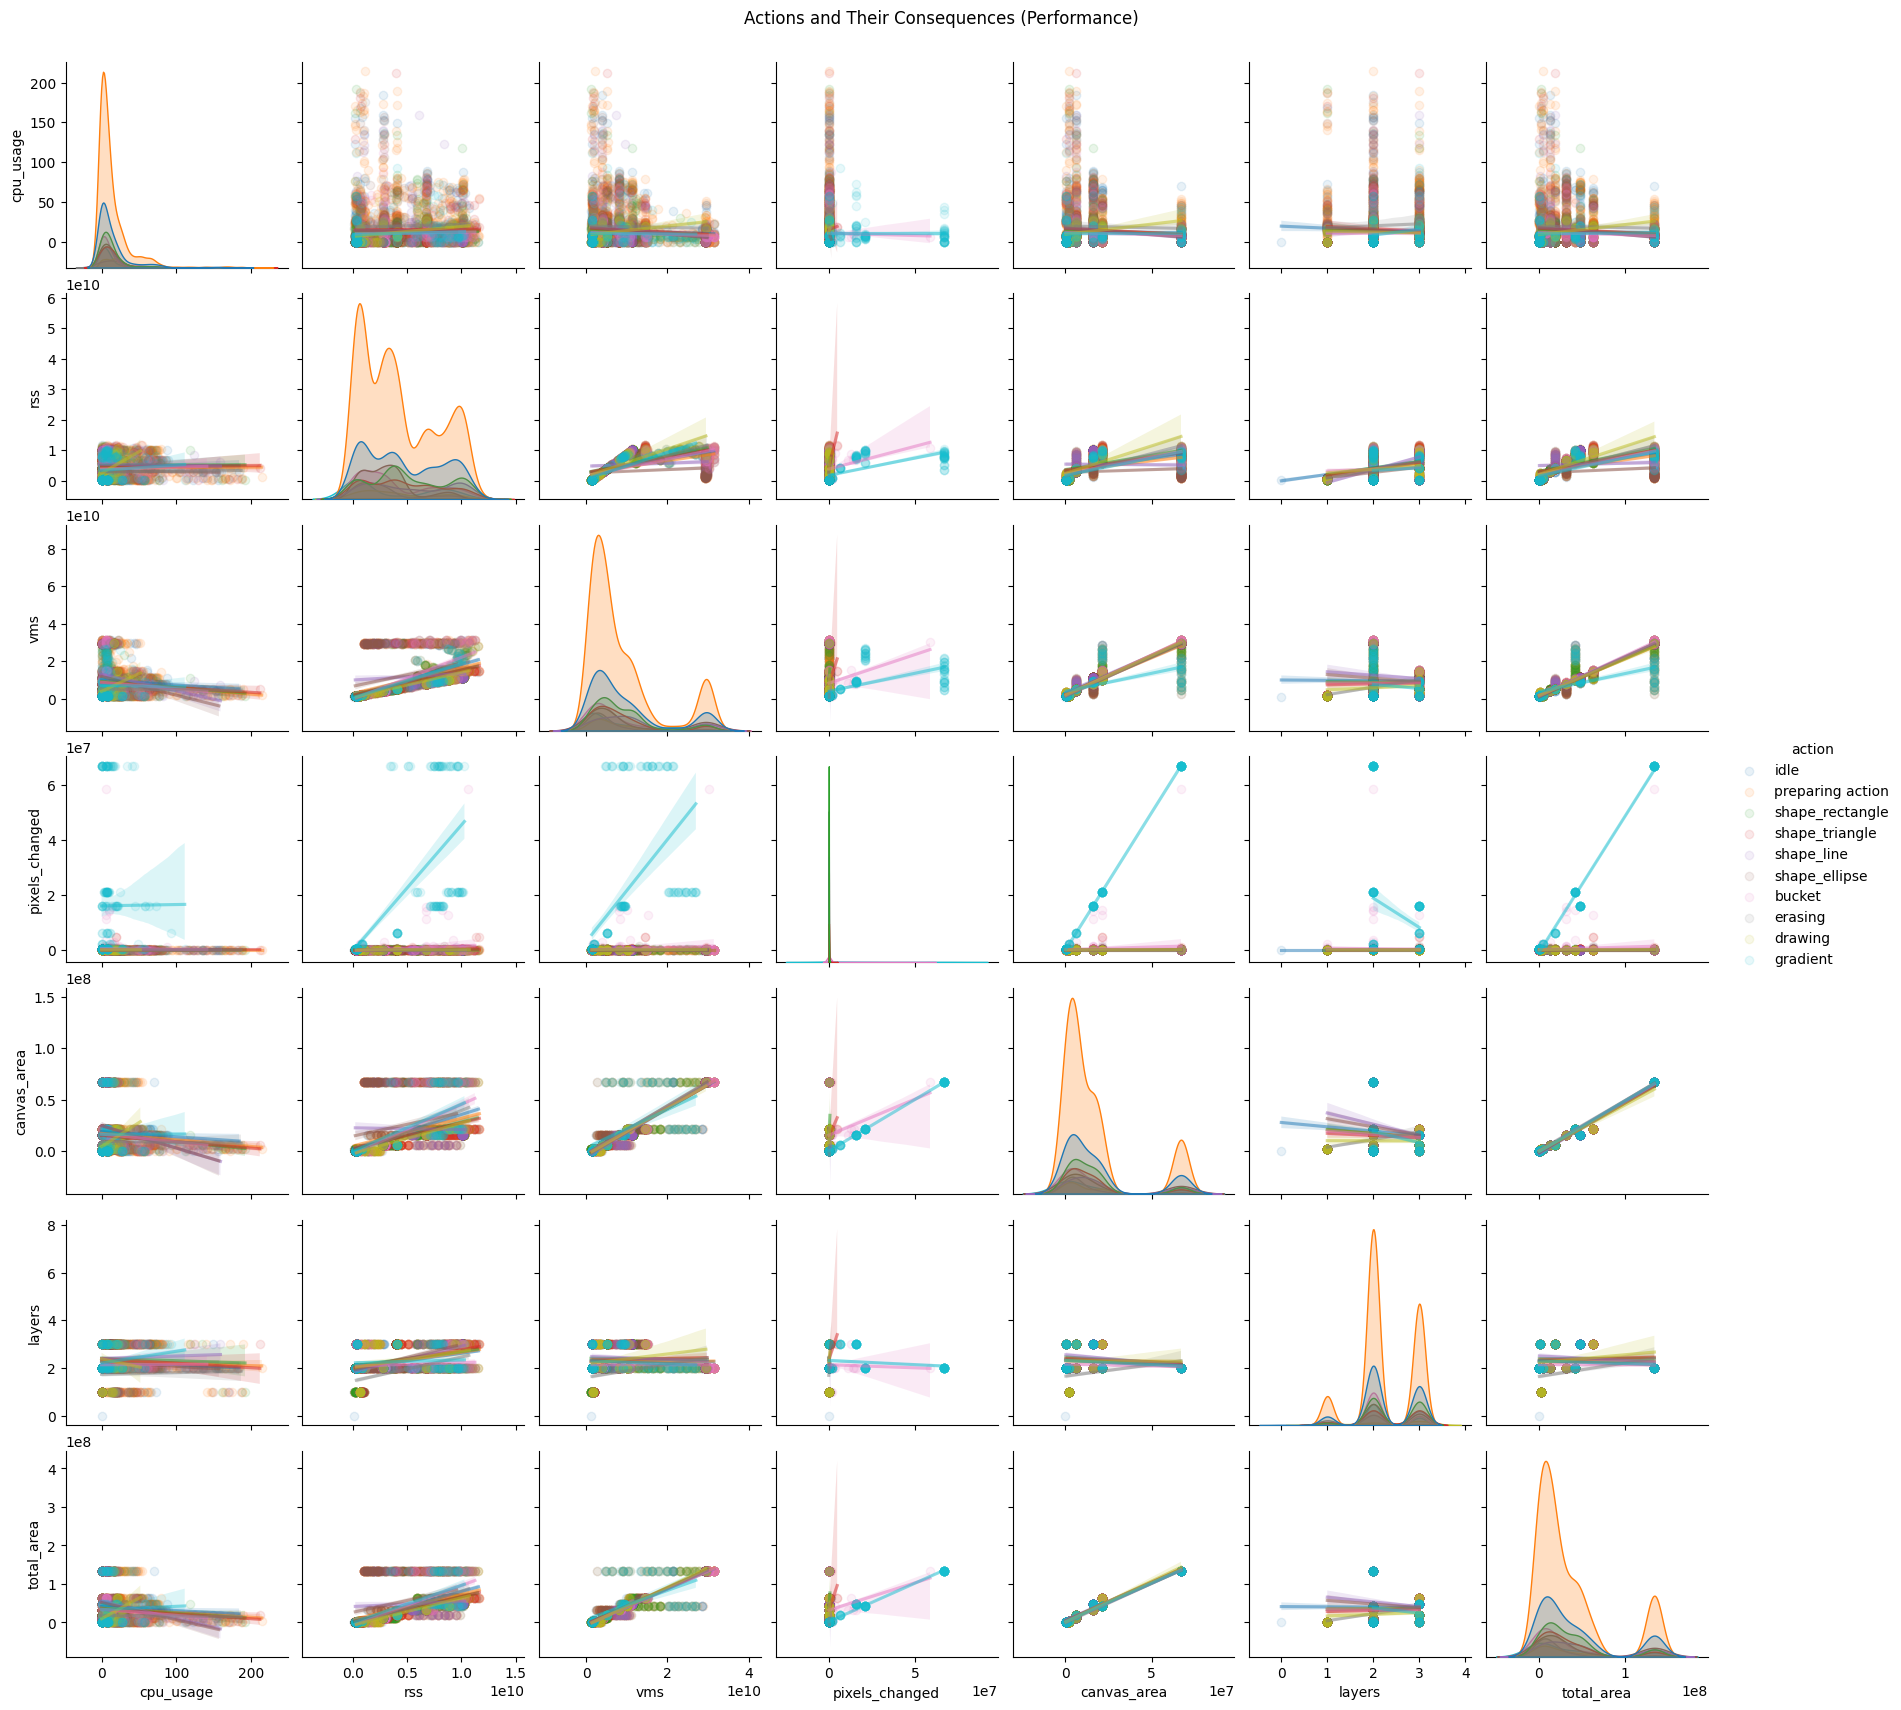

In [132]:
g = sns.pairplot(df.iloc[:,1:], hue = "action", kind='reg', plot_kws={'line_kws':{'alpha' : 0.5}, 'scatter_kws': {'alpha': 0.1}})
g.figure.suptitle("Actions and Their Consequences (Performance)")
plt.subplots_adjust(top=0.95)
plt.show()

# Analysis
The most impactful variable on performance was the total area of the canvas. Considering that Drawable redraws the whole canvas every time an image (even a small portion of bit) is updated, it makes sense that so much of the program is in memory. Additionally, copies of the state are constantly being saved in deques, and while a snapshot may not capture the entire application, it does mean more memory is needed to kepe the snapshot. Noteably, however, almost no variable had even a slightly positive correlation with CPU_usage, indicating that calculations are significantly more efficient than the memory management. In a prior iteration, the bucket tool used to be quite computationally expensive, but considering that most of the program is single-threaded, with trackers being the sole exception, the processor likely is being bottlenecked by a (mostly) single-threaded implementation. If Drawable was multi-thread compatible, then the same memory could be re-used, reducing the effective memory needed. Ultimately though, in the future, there are many ways to improve the application.